# SAM3 SageMaker real-time endpoint

This notebook packages a fine-tuned (or pretrained) SAM3 checkpoint and
deploys it as a SageMaker real-time endpoint, then invokes it with a
text-prompt request and a click-prompt request.

**Inputs** (local):

- `CHECKPOINT_PATH` → local SAM3 checkpoint (e.g. the merged file that
  the training notebook produced). Set to `None` to deploy `facebook/sam3`
  and let the handler pull weights from HuggingFace on container boot.
- `BPE_PATH`        → `sam3/assets/bpe_simple_vocab_16e6.txt.gz`
- `INFERENCE_DIR`   → `sagemaker/deploy/` (contains `inference.py` +
  `requirements.txt`; both get packaged under `code/` in the tarball).

**Outputs**:

- `s3://<bucket>/<prefix>/model.tar.gz` — the model bundle SageMaker
  imports on container boot.
- A running endpoint at `<ENDPOINT_NAME>` (billed hourly until deleted).

## Prerequisites

```bash
pip install 'sagemaker>=2.230,<3' boto3 pycocotools pillow
aws configure   # or assume an IAM role with sagemaker:*, iam:PassRole, s3 access
```

The IAM role passed to the endpoint (`ROLE`) needs `AmazonS3ReadOnlyAccess`
on the bucket + the standard SageMaker execution policy.

**Cost warning**: an `ml.g5.xlarge` endpoint is ~$1.40/hr on-demand.
Section 5 deletes the endpoint — run it when done.

In [1]:
# Pin sagemaker<3 — the v3 SDK is a major rewrite that moves PyTorchModel /
# Session / get_execution_role out of their canonical paths. This notebook
# targets the long-stable v2 API (same as launch_training.ipynb).
%pip install --quiet 'sagemaker>=2.230,<3' boto3 pycocotools pillow
# IMPORTANT: if the kernel already imported a v3 build, restart it before
# running the next cell.

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ---------- Configuration: edit these ----------
import os
import sagemaker
import boto3

_v = getattr(sagemaker, "__version__", "unknown")
if _v.startswith("3.") or _v.startswith("4."):
    raise RuntimeError(
        f"Detected sagemaker {_v}, but this notebook requires v2.x. "
        f"Run the previous cell, then RESTART THE KERNEL, then retry."
    )
print("sagemaker version:", _v)

from sagemaker import get_execution_role

sess   = sagemaker.Session()
role   = get_execution_role()
bucket = sess.default_bucket()
region = sess.boto_session.region_name
print("sagemaker_default_bucket:", bucket)
print("sagemaker_region:", region)

# ---- Repo + local artifact paths ----
LOCAL_REPO_ROOT = "/home/ec2-user/SageMaker/efs/Projects/sam3"
# Set to a local .pt file to bundle a fine-tuned checkpoint, or leave as
# None to deploy facebook/sam3 unmodified (handler auto-pulls from HF).
CHECKPOINT_PATH = os.path.join(
    LOCAL_REPO_ROOT, "runs/aws_sam_finetune/checkpoints/checkpoint_merged.pt"
)
# CHECKPOINT_PATH = None   # ← uncomment to deploy pretrained SAM3

BPE_PATH       = os.path.join(LOCAL_REPO_ROOT, "sam3/assets/bpe_simple_vocab_16e6.txt.gz")
INFERENCE_DIR  = os.path.join(LOCAL_REPO_ROOT, "sagemaker/deploy")

# ---- S3 layout ----
S3_PREFIX  = "projects/sam3/deploy/aws_sam_v1"
S3_TARBALL = f"s3://{bucket}/{S3_PREFIX}/model.tar.gz"

# ---- Endpoint settings ----
INSTANCE_TYPE      = "ml.g5.xlarge"          # 1 × A10G 24GB — comfortable for 1008×1008 inference
INSTANCE_COUNT     = 1
# Endpoint name is `<base>-<timestamp>`, assembled in the deploy cell.
# Each deploy call creates a fresh endpoint (no in-place update), so
# redeploys never collide with existing configs. Downstream callers must
# re-read `ENDPOINT_NAME` after every redeploy.
ENDPOINT_NAME_BASE = "sam3-aws-sam"
FRAMEWORK_VERSION  = "2.3.0"
PY_VERSION         = "py311"

# Local scratch for the assembled tarball
LOCAL_TARBALL = os.path.join(LOCAL_REPO_ROOT, "tmp", "s3_sagemaker_deploy", "model.tar.gz")

print("checkpoint:  ", CHECKPOINT_PATH or "(pretrained facebook/sam3 from HF)")
print("bpe:         ", BPE_PATH)
print("inference:   ", INFERENCE_DIR)
print("s3 tarball:  ", S3_TARBALL)
print("endpoint base:", ENDPOINT_NAME_BASE, "on", INSTANCE_TYPE)


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ubuntu/.config/sagemaker/config.yaml
sagemaker version: 2.257.3
sagemaker_default_bucket: sagemaker-us-west-2-452145973879
sagemaker_region: us-west-2
checkpoint:   /home/ec2-user/SageMaker/efs/Projects/sam3/runs/aws_sam_finetune/checkpoints/checkpoint_merged.pt
bpe:          /home/ec2-user/SageMaker/efs/Projects/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz
inference:    /home/ec2-user/SageMaker/efs/Projects/sam3/sagemaker/deploy
s3 tarball:   s3://sagemaker-us-west-2-452145973879/projects/sam3/deploy/aws_sam_v1/model.tar.gz
endpoint base: sam3-aws-sam on ml.g5.xlarge


## 1. Build the model tarball

SageMaker's PyTorch inference container expects this layout inside
`model.tar.gz`:

```
checkpoint.pt                       # optional — handler falls back to HF
bpe_simple_vocab_16e6.txt.gz
code/
  inference.py                      # model_fn / input_fn / predict_fn / output_fn
  requirements.txt                  # extra pip deps installed on container boot
  sam3/                             # ← vendored working-tree sam3 package
    __init__.py
    model_builder.py
    model/, sam/, ...
```

The `code/sam3/` copy is what makes the endpoint use *this* fork's code
(with the click-training patches + custom state-dict keys) instead of
whatever `pip install sam3` from PyPI would give you. Bundling the
source directly also sidesteps the "private repo needs a PAT" problem
for `pip install git+https://...` from inside the container.

Staging + tarball assembly happens in `tmp/s3_sagemaker_deploy/`
(under `.gitignore`).

In [3]:
import shutil
import tarfile
from pathlib import Path

STAGING_DIR = os.path.join(LOCAL_REPO_ROOT, "tmp", "s3_sagemaker_deploy", "staging")
if os.path.exists(STAGING_DIR):
    shutil.rmtree(STAGING_DIR)
os.makedirs(STAGING_DIR)

# Top-level: checkpoint + BPE vocab
if CHECKPOINT_PATH is not None:
    assert os.path.exists(CHECKPOINT_PATH), f"missing checkpoint: {CHECKPOINT_PATH}"
    shutil.copy(CHECKPOINT_PATH, os.path.join(STAGING_DIR, "checkpoint.pt"))
    print(f"  + checkpoint.pt  ({os.path.getsize(CHECKPOINT_PATH)/1e9:.2f} GB)")
else:
    print("  (no checkpoint bundled — handler will pull facebook/sam3 from HF)")
shutil.copy(BPE_PATH, os.path.join(STAGING_DIR, os.path.basename(BPE_PATH)))
print(f"  + {os.path.basename(BPE_PATH)}")

# code/ subdir — SageMaker adds this to sys.path and imports inference.py
# from it, and pip-installs code/requirements.txt on container boot.
code_dst = os.path.join(STAGING_DIR, "code")
os.makedirs(code_dst)
for fname in ("inference.py", "requirements.txt"):
    src = os.path.join(INFERENCE_DIR, fname)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(code_dst, fname))
        print(f"  + code/{fname}")
    else:
        print(f"  ! code/{fname} missing at {src}")

# Vendor the working-tree sam3/ package into code/sam3/.
#
# WHY: this fork is a PRIVATE repo (Chevolier/sam3), so `pip install
# git+https://...` inside the container would need a PAT baked into the
# tarball. Copying the source instead avoids the credential leak and
# also cuts ~1–2 min off container boot (no git clone, no wheel build).
#
# `from sam3 import ...` inside inference.py resolves to this copy
# because SageMaker prepends /opt/ml/model/code to sys.path before
# calling model_fn.
#
# NOTE: `sam3/train/` MUST be included even though inference doesn't
# directly touch the trainer. sam3/model/sam3_tracker_base.py:14 does
# `from sam3.train.data.collator import BatchedDatapoint` at import
# time, and model_builder eagerly imports sam3_tracker_base. Dropping
# `train/` from the tarball crashes model_fn with:
#   ModuleNotFoundError: No module named 'sam3.train'
# (verified in CloudWatch on the previous deploy attempt).
sam3_src = os.path.join(LOCAL_REPO_ROOT, "sam3")
sam3_dst = os.path.join(code_dst, "sam3")
shutil.copytree(
    sam3_src, sam3_dst,
    ignore=shutil.ignore_patterns(
        "__pycache__", "*.pyc", "*.pyo",
        ".ipynb_checkpoints", ".pytest_cache", ".mypy_cache",
        "*.egg-info", "build", "dist",
    ),
)
n_files = sum(1 for _ in Path(sam3_dst).rglob("*") if _.is_file())
size_mb = sum(p.stat().st_size for p in Path(sam3_dst).rglob("*") if p.is_file()) / 1e6
print(f"  + code/sam3/  ({n_files} files, {size_mb:.1f} MB)")

# Tar it up.
os.makedirs(os.path.dirname(LOCAL_TARBALL), exist_ok=True)
if os.path.exists(LOCAL_TARBALL):
    os.remove(LOCAL_TARBALL)
with tarfile.open(LOCAL_TARBALL, "w:gz") as tf:
    for p in Path(STAGING_DIR).rglob("*"):
        tf.add(p, arcname=p.relative_to(STAGING_DIR))

print(f"\nlocal tarball: {LOCAL_TARBALL}")
print(f"size:          {os.path.getsize(LOCAL_TARBALL)/1e9:.2f} GB")


  + checkpoint.pt  (3.45 GB)
  + bpe_simple_vocab_16e6.txt.gz
  + code/inference.py
  + code/requirements.txt
  + code/sam3/  (199 files, 4.8 MB)

local tarball: /home/ec2-user/SageMaker/efs/Projects/sam3/tmp/s3_sagemaker_deploy/model.tar.gz
size:          3.21 GB


## 2. Upload the tarball to S3

In [4]:
from sagemaker.s3 import S3Uploader

boto_session = boto3.Session(region_name=region)
sagemaker_session = sagemaker.Session(boto_session=boto_session)

model_data = S3Uploader.upload(
    local_path=LOCAL_TARBALL,
    desired_s3_uri=f"s3://{bucket}/{S3_PREFIX}",
    sagemaker_session=sagemaker_session,
)
print("uploaded:", model_data)

uploaded: s3://sagemaker-us-west-2-452145973879/projects/sam3/deploy/aws_sam_v1/model.tar.gz


## 3. Deploy the endpoint

SageMaker downloads the tarball, extracts it to `/opt/ml/model/`, pip-installs
`code/requirements.txt`, imports `code/inference.py`, and calls `model_fn`
once per worker. First-boot pip install + weight load takes ~10 minutes
for SAM3; subsequent restarts on the same instance are much faster.

Every run of this cell creates a **new** endpoint with a UTC-timestamped
name (`<ENDPOINT_NAME_BASE>-YYYYMMDD-HHMMSS`), plus a matching
`EndpointConfig` and `Model`. This sidesteps SageMaker's "cannot create
already existing endpoint configuration" error and lets you keep two
deployed versions side-by-side for comparison.

The variable `ENDPOINT_NAME` gets (re)bound in this cell — subsequent
invoke cells pick it up automatically. Save it off if you want to reach
the endpoint from another kernel.

In [5]:
from datetime import datetime, timezone
from sagemaker.pytorch import PyTorchModel

# Timestamp EVERYTHING — endpoint, config, model — with a single stamp
# so redeploys can't collide. Downside vs. a stable endpoint name is
# that clients have to re-read `ENDPOINT_NAME` after each redeploy
# instead of hardcoding a URL. Upside is you can run this cell N times
# without any cleanup and never see "already existing" errors, and you
# can compare two deployed versions side-by-side.
STAMP = datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")
ENDPOINT_NAME = f"{ENDPOINT_NAME_BASE}-{STAMP}"
MODEL_NAME    = ENDPOINT_NAME   # SDK derives EndpointConfigName from Model.name
print(f"endpoint name:  {ENDPOINT_NAME}")
print(f"model name:     {MODEL_NAME}")

model = PyTorchModel(
    model_data=model_data,
    role=role,
    framework_version=FRAMEWORK_VERSION,
    py_version=PY_VERSION,
    entry_point="inference.py",
    sagemaker_session=sagemaker_session,
    name=MODEL_NAME,           # drives EndpointConfig + Model naming
    env={
        # Pre-cache HF home so first request doesn't time out if the handler
        # decides to fetch facebook/sam3 (only happens when CHECKPOINT_PATH
        # is None). Set HF_TOKEN here only if the endpoint role can't read
        # from HF unauthenticated.
        "TRANSFORMERS_CACHE": "/opt/ml/model/.hf_cache",
        "HF_HOME":            "/opt/ml/model/.hf_cache",
    },
)

predictor = model.deploy(
    initial_instance_count=INSTANCE_COUNT,
    instance_type=INSTANCE_TYPE,
    endpoint_name=ENDPOINT_NAME,
)
print("endpoint ready:", predictor.endpoint_name)


endpoint name:  sam3-aws-sam-20260701-092709
model name:     sam3-aws-sam-20260701-092709
---------!endpoint ready: sam3-aws-sam-20260701-092709


## 4. Smoke-test the endpoint

Two request modes:

- **text**    — give the model a noun phrase, it returns 0..N masks.
- **click**   — SAM-1-style interactive: points + labels, up to 3 masks back.

Masks come back as COCO-RLE. `pycocotools.mask.decode` reconstructs the
binary mask locally.

In [26]:
# ---- Text-prompt request ----
#
# The boto3 default socket read-timeout is 60 s. The FIRST invocation
# after deploy takes much longer (cuDNN plan search + CUDA context init
# + torch compile on the ViT trunk — commonly 60–120 s on ml.g5.xlarge
# for a 1008×1008 input). Use a client with a longer read-timeout, and
# do one throwaway warm-up call before timing anything.
import base64
import json
from botocore.config import Config

# IMAGE_PATH = os.path.join(LOCAL_REPO_ROOT, "data/AWS_SAM/companypremises2025101600217.png")
# IMAGE_PATH = os.path.join(LOCAL_REPO_ROOT, "data/AWS_SAM/waterpipe_2023_09_08 000026118.png")
IMAGE_PATH = os.path.join(LOCAL_REPO_ROOT, "data/AWS_SAM/2_camera1_color_image_raw_131.jpg")
TEXT_PROMPT = "grass"
# TEXT_PROMPT = "building"

with open(IMAGE_PATH, "rb") as f:
    img_b64 = base64.b64encode(f.read()).decode("ascii")

body = {
    "mode": "text",
    "image_b64": img_b64,
    "text": TEXT_PROMPT,
    "confidence": 0.3,
}

# 5-minute read timeout; boto retries transient network errors 3x.
smr_cfg = Config(
    read_timeout=300,
    connect_timeout=10,
    retries={"max_attempts": 3, "mode": "standard"},
)
smr = boto_session.client("sagemaker-runtime", config=smr_cfg)

# --- warm-up call (cold-start amortization) ---
# Send a tiny 32×32 placeholder to force model_fn to finish loading the
# checkpoint, allocate CUDA context, and JIT-compile the graph. If model
# init already ran on a previous cell run, this is a fast no-op.
import io
from PIL import Image
warmup_img = Image.new("RGB", (32, 32), color=(128, 128, 128))
buf = io.BytesIO()
warmup_img.save(buf, format="PNG")
warmup_b64 = base64.b64encode(buf.getvalue()).decode("ascii")
try:
    smr.invoke_endpoint(
        EndpointName=ENDPOINT_NAME,
        ContentType="application/json",
        Body=json.dumps({"mode": "text", "image_b64": warmup_b64, "text": "warmup"}),
    )
    print("warm-up call ✓")
except Exception as e:
    print(f"warm-up call failed (this may be fine on a fresh endpoint): {e}")

# --- real invocation ---
resp = smr.invoke_endpoint(
    EndpointName=ENDPOINT_NAME,
    ContentType="application/json",
    Body=json.dumps(body),
)
out = json.loads(resp["Body"].read())
print(f"text='{TEXT_PROMPT}'  n_masks={len(out['masks_rle'])}  scores={out['scores']}")
print(f"image_size={out['image_size']}")


warm-up call ✓
text='grass'  n_masks=1  scores=[0.96875]
image_size=[720, 1280]


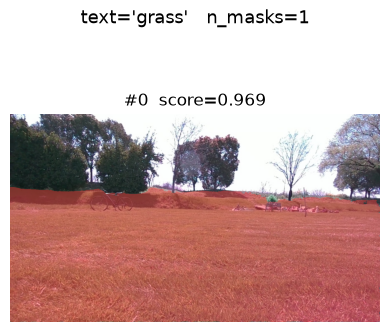

In [27]:
# ---- Visualize text-prompt masks ----
# Uses `out` from the invoke-text cell above. Draws each returned
# mask as a colored overlay on top of the source image, with the
# score in the tile title.
import numpy as np
from PIL import Image
from pycocotools import mask as mask_utils
import matplotlib.pyplot as plt

image = np.array(Image.open(IMAGE_PATH).convert("RGB"))

masks = [mask_utils.decode(rle).astype(bool) for rle in out.get("masks_rle", [])]
scores = out.get("scores", [])

n = len(masks)
if n == 0:
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(image)
    ax.set_title(f"text='{TEXT_PROMPT}'  →  no masks returned")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    # Cycle through contrasting colors so overlapping instances
    # remain visually separable.
    palette = np.array([
        [255,  60,  60],
        [ 60, 200,  90],
        [ 60, 130, 255],
        [230, 200,  30],
        [200,  80, 240],
        [ 30, 220, 220],
    ], dtype=np.uint8)

    ncols = min(4, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, ax in enumerate(axes):
        if i >= n:
            ax.axis("off")
            continue
        m = masks[i]
        color = palette[i % len(palette)]
        overlay = image.copy()
        overlay[m] = (0.55 * overlay[m] + 0.45 * color).astype(np.uint8)
        ax.imshow(overlay)
        score = scores[i] if i < len(scores) else float("nan")
        ax.set_title(f"#{i}  score={score:.3f}")
        ax.axis("off")

    fig.suptitle(f"text='{TEXT_PROMPT}'   n_masks={n}", fontsize=13)
    plt.tight_layout()
    plt.show()


In [18]:
# ---- Click-prompt request ----
# Uses the same long-timeout client (`smr`) built in the previous cell.
CLICK_XY = [520, 375]     # (x, y) pixel, positive click

body = {
    "mode": "click",
    "image_b64": img_b64,
    "points": [CLICK_XY],
    "labels": [1],                # 1 = positive, 0 = negative
    "multimask_output": True,     # returns 3 candidate masks
}
resp = smr.invoke_endpoint(
    EndpointName=ENDPOINT_NAME,
    ContentType="application/json",
    Body=json.dumps(body),
)
out = json.loads(resp["Body"].read())
print(f"click={CLICK_XY}  n_masks={len(out['masks_rle'])}  scores={out['scores']}")


click=[520, 375]  n_masks=3  scores=[0.01031494140625, 0.99609375, 0.51171875]


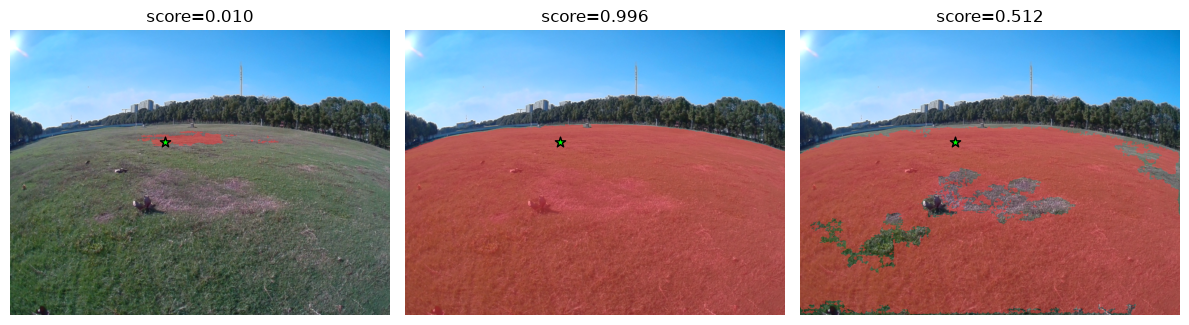

In [19]:
# ---- Decode + visualize the returned masks ----
import numpy as np
from PIL import Image
from pycocotools import mask as mask_utils
import matplotlib.pyplot as plt

image = np.array(Image.open(IMAGE_PATH).convert("RGB"))
masks = [mask_utils.decode(rle).astype(bool) for rle in out["masks_rle"]]

fig, axes = plt.subplots(1, max(1, len(masks)), figsize=(4 * max(1, len(masks)), 4))
if len(masks) <= 1:
    axes = [axes]
for ax, m, s in zip(axes, masks, out["scores"]):
    overlay = image.copy()
    overlay[m] = (0.5 * overlay[m] + 0.5 * np.array([255, 60, 60])).astype(np.uint8)
    ax.imshow(overlay)
    ax.scatter([CLICK_XY[0]], [CLICK_XY[1]], c="lime", s=60, marker="*", edgecolors="black")
    ax.set_title(f"score={s:.3f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Cleanup

**Endpoints are billed hourly until deleted.** Run this cell when you're
done — leaving `ml.g5.xlarge` running is ~$34/day.

In [9]:
# # Delete the CURRENT endpoint + all sibling endpoints/configs/models
# # whose name starts with ENDPOINT_NAME_BASE-. Because every deploy in
# # this notebook creates a fresh set of timestamped resources, this
# # sweep is the intended way to clean up.
# sm = boto_session.client("sagemaker")

# # Also delete the current-cell's endpoint (if the deploy cell has run
# # in this kernel session, ENDPOINT_NAME is defined and pointed at the
# # most recent deployment).
# current = ENDPOINT_NAME if "ENDPOINT_NAME" in dir() else None
# if current:
#     print(f"current endpoint: {current}")

# def _sweep(op_name, list_call, list_key, name_key, delete_kw):
#     """Delete every resource returned by `list_call` whose Name starts with the prefix."""
#     try:
#         resp = list_call(NameContains=f"{ENDPOINT_NAME_BASE}-", MaxResults=100)
#     except sm.exceptions.ClientError as e:
#         print(f"list failed for {op_name}: {e}")
#         return
#     for item in resp.get(list_key, []):
#         name = item[name_key]
#         try:
#             getattr(sm, op_name)(**{delete_kw: name})
#             print(f"✓ {op_name} {name}")
#         except sm.exceptions.ClientError as e:
#             print(f"  skip {op_name} {name}: {e}")

# # Order matters: endpoints reference configs, configs reference models.
# _sweep("delete_endpoint",        sm.list_endpoints,         "Endpoints",       "EndpointName",       "EndpointName")
# _sweep("delete_endpoint_config", sm.list_endpoint_configs,  "EndpointConfigs", "EndpointConfigName", "EndpointConfigName")
# _sweep("delete_model",           sm.list_models,            "Models",          "ModelName",          "ModelName")

# # S3 tarball stays put — uncomment to remove:
# # boto3.client("s3").delete_object(Bucket=bucket, Key=f"{S3_PREFIX}/model.tar.gz")


## Notes / gotchas

- **First boot is slow** because `sam3` gets pip-installed from GitHub
  inside the container (see `requirements.txt`). If you deploy often,
  build a custom Docker image with `sam3` baked in and pass `image_uri=...`
  to `PyTorchModel(...)` instead of `framework_version`.
- **`entry_point="inference.py"`** — SageMaker resolves this against
  the `code/` subdir it extracts from the tarball, NOT against a local
  filesystem path. You don't need to pass `source_dir` because the
  package layout already puts everything under `code/`.
- **HuggingFace download**: if `CHECKPOINT_PATH is None`, `model_fn`
  calls `build_sam3_image_model(load_from_HF=True, ...)`. The endpoint
  role needs internet access + `TRANSFORMERS_CACHE` set (done above),
  and optionally `HF_TOKEN` for gated repos.
- **First-invocation `ReadTimeoutError`**: the default `boto3` socket
  read-timeout is 60 s. The FIRST invoke after deploy can take 60–120 s
  on `ml.g5.xlarge` (CUDA context + cuDNN plan search + first-pass model
  forward). The invoke cell above builds an SMR client with
  `read_timeout=300` and sends a tiny 32×32 warm-up request first, so
  the timed call comes back in <1 s. If it still times out:
  - `aws logs tail /aws/sagemaker/Endpoints/<ENDPOINT_NAME> --follow` —
    look for `ModuleNotFoundError`, `CUDA out of memory`, or an
    unhandled exception in `model_fn`.
  - `aws sagemaker describe-endpoint --endpoint-name <name>` — the
    `EndpointStatus` should be `InService`.
- **Cold vs warm invocations**: warm p50 for a 1008×1008 text prompt is
  ~200–300 ms on `ml.g5.xlarge`.
- **Autoscaling**: for production, wrap this endpoint with an
  application-autoscaling target policy (SageMaker docs: "Add automatic
  scaling to a model deployed to a real-time endpoint").
- **Multi-model endpoints** are NOT supported here — the SAM3 model
  is stateful (`model_fn` returns a live processor) and multi-model
  endpoints re-instantiate models per invocation.